In [203]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [204]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [205]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [206]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [207]:
X_trainval.shape

torch.Size([60000, 1, 28, 28])

In [208]:
train_dataset = TensorDataset(X_trainval.to(device), y_trainval.to(device))
test_dataset = TensorDataset(X_test.to(device), y_test.to(device))

test_loader = DataLoader(test_dataset, batch_size=1000)

In [209]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Thanx to https://medium.com/data-science-collective/implementing-cnn-in-pytorch-testing-on-mnist-99-26-test-accuracy-5c63876c6ac8
        self.model = nn.Sequential(
            nn.ZeroPad2d(2),
            nn.Conv2d(1, 16, 5, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(out_features=10),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_batch = None
        self.best_val_loss = None

    def forward(self, x):
        x = self.model(x)
        return x


In [210]:
def train_one_model(max_epochs: int, batch_size: int, lr: float) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    val_loss_per_batch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            val_loss_per_batch[epoch] = loss_avg

            # if epoch % print_every == 0:
            #     print(f"{epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_batch = val_loss_per_batch
    model.best_val_loss = np.min(val_loss_per_batch).item()

    model.eval()
    return model

In [211]:
batch_sizes = [
    4096,
    2048,
    1024,
    512,
    256,
    128,
    64,
    32,
    16,
    8,
]

learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1,
]

models = np.zeros((len(batch_sizes), len(learning_rates)), dtype=object)

training_durations = np.zeros_like(models, dtype=float)

for i, batch_size in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        lr = 0.1

        start = time.time()
        model = train_one_model(5, batch_size, lr)
        duration = time.time() - start

        models[i, j] = model
        training_durations[i, j] = duration

        perc_done = 100*(i*models.shape[1] + j + 1)//models.size
        print(f"[{perc_done:3n}%] model ({i}, {j}) trained with best val loss = {model.best_val_loss}")

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


[  2%] model (0, 0) trained with best val loss = 0.37459694445133207
[  4%] model (0, 1) trained with best val loss = 2.301324224472046
[  6%] model (0, 2) trained with best val loss = 0.9562082588672638
[  8%] model (0, 3) trained with best val loss = 2.2654582262039185
[ 10%] model (0, 4) trained with best val loss = 2.3011653661727904
[ 12%] model (1, 0) trained with best val loss = 0.2472049281001091
[ 14%] model (1, 1) trained with best val loss = 0.38702407479286194
[ 16%] model (1, 2) trained with best val loss = 2.3012243270874024
[ 18%] model (1, 3) trained with best val loss = 0.347141170501709
[ 20%] model (1, 4) trained with best val loss = 0.4641614258289337
[ 22%] model (2, 0) trained with best val loss = 0.18953558802604675
[ 24%] model (2, 1) trained with best val loss = 0.29329459816217424
[ 26%] model (2, 2) trained with best val loss = 2.301640820503235
[ 28%] model (2, 3) trained with best val loss = 0.15065134018659593
[ 30%] model (2, 4) trained with best val loss

In [212]:
losses = np.vectorize(lambda m: m.best_val_loss)(models)
losses

array([[0.37459694, 2.30132422, 0.95620826, 2.26545823, 2.30116537],
       [0.24720493, 0.38702407, 2.30122433, 0.34714117, 0.46416143],
       [0.18953559, 0.2932946 , 2.30164082, 0.15065134, 0.32343419],
       [0.3214469 , 0.27551547, 0.26669143, 0.14851264, 0.2861272 ],
       [2.30358858, 0.15366429, 0.30340774, 0.26616912, 0.13613633],
       [0.18330593, 2.30422618, 0.28885257, 0.17140796, 0.27216653],
       [0.24534706, 2.30331855, 2.30830705, 0.25413763, 0.30578575],
       [0.24027578, 0.26643267, 2.30678804, 0.34007529, 0.33216169],
       [0.40717683, 0.46169968, 2.3075093 , 2.30847113, 2.30638404],
       [2.31830657, 2.31684742, 2.31833193, 0.64922523, 2.30957973]])

<Axes: >

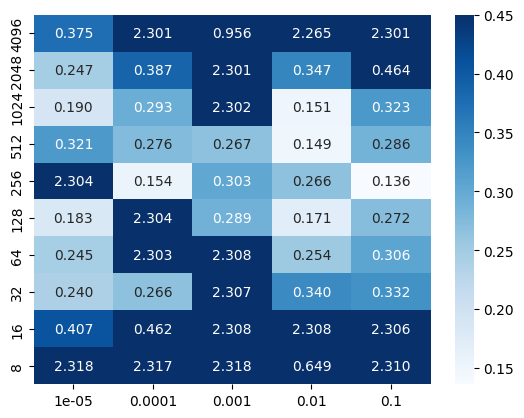

In [213]:
sns.heatmap(losses, annot=True, vmax=0.45, fmt=".3f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

<Axes: >

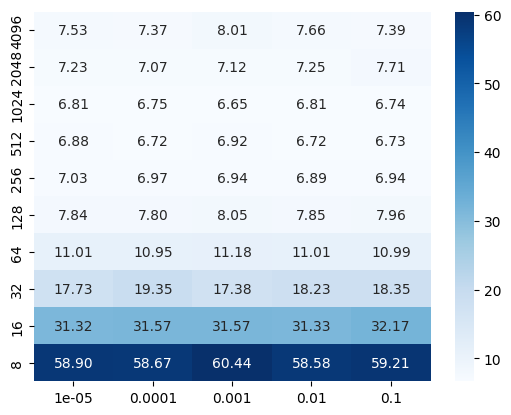

In [214]:
sns.heatmap(training_durations, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

In [215]:
inv_training_eff = losses*training_durations

inv_training_eff

array([[  2.82249432,  16.95770203,   7.66342909,  17.34309269,
         17.01035036],
       [  1.78662487,   2.73576716,  16.38177067,   2.51658693,
          3.58011174],
       [  1.29146398,   1.97992489,  15.29637543,   1.02659992,
          2.17997185],
       [  2.21215781,   1.85111045,   1.84513634,   0.99761524,
          1.92472224],
       [ 16.19938592,   1.07114467,   2.10428545,   1.83523265,
          0.94473505],
       [  1.43633945,  17.96688369,   2.32603844,   1.34504662,
          2.16680754],
       [  2.7023999 ,  25.21483294,  25.81750507,   2.79681074,
          3.36049752],
       [  4.25975542,   5.15621721,  40.10208669,   6.20097897,
          6.0951334 ],
       [ 12.75391882,  14.57411281,  72.85914698,  72.32968349,
         74.20649864],
       [136.53823044, 135.93227587, 140.11872967,  38.02965027,
        136.73951904]])

<Axes: >

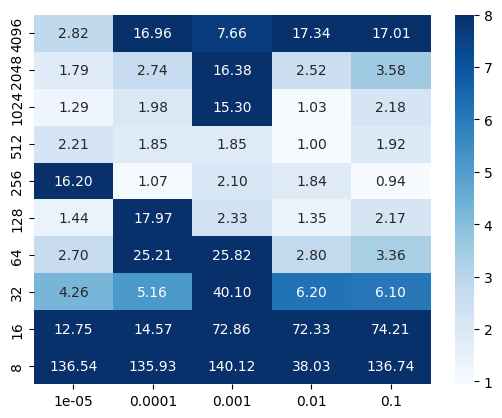

In [219]:
sns.heatmap(inv_training_eff, annot=True, vmax=8, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

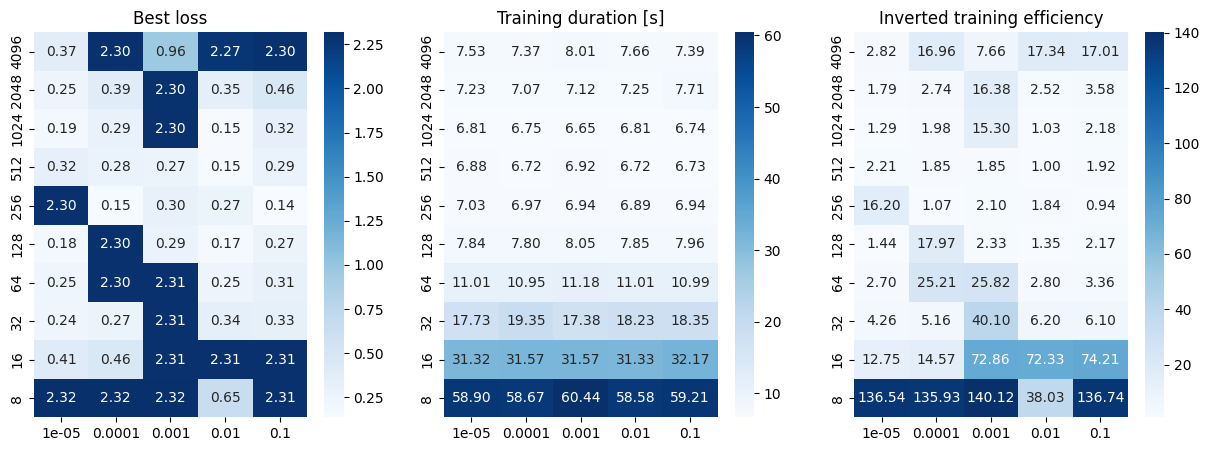

In [217]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Best loss", "Training duration [s]", "Inverted training efficiency"]
for ax, arr, title in zip(axs, [losses, training_durations, inv_training_eff], titles):
    sns.heatmap(arr, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues", ax=ax)
    ax.set_title(title)

plt.show()
